# 지하철이용정보분석
- https://data.busan.go.kr/bdip/
- 승하차 인원정보 검색하기
- 일별역별시간대별승하차 파일 받기
- 최신 csv 파일로 저장

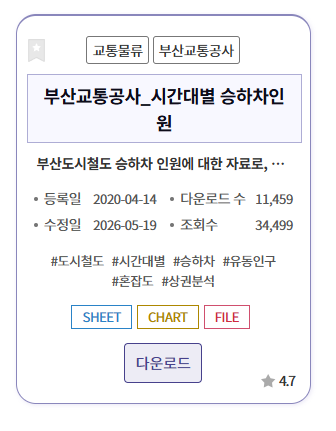

In [1]:
import pandas as pd
file_path = './dataset/일별역별시간대별승하차202604.csv'
df = pd.read_csv(file_path, encoding="EUC-KR")
df[df['역명']=='경성대부경대']

,역번호,역명,년월일,요일,구분,합계,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
3162,212,경성대부경대,2026-01-01,목,승차,7668,0,0,0,6,...,567,676,605,485,350,341,312,234,132,11
3163,212,경성대부경대,2026-01-01,목,하차,7722,0,0,0,0,...,542,586,584,615,494,379,529,428,259,79
3164,212,경성대부경대,2026-01-02,금,승차,14210,0,0,0,1,...,1108,1216,1323,1403,716,595,504,421,266,14
3165,212,경성대부경대,2026-01-02,금,하차,14807,0,0,0,0,...,886,1020,1276,1931,983,608,649,603,379,84
3166,212,경성대부경대,2026-01-03,토,승차,11382,0,0,0,1,...,947,1108,998,736,529,465,395,353,225,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23275,212,경성대부경대,2026-04-28,화,하차,23411,0,0,0,1,...,945,1176,1501,2150,977,743,762,810,345,115
23276,212,경성대부경대,2026-04-29,수,승차,22434,0,0,0,0,...,1781,2648,2718,2024,960,848,738,591,414,13
23277,212,경성대부경대,2026-04-29,수,하차,22814,3,0,0,0,...,947,1156,1501,2110,1001,770,710,720,559,94
23278,212,경성대부경대,2026-04-30,목,승차,25420,0,0,0,3,...,2015,3005,3147,2484,1196,1031,948,676,399,13


In [2]:
columns0 = ['num', 'name', 'date', 'week', 'type', 'total']
time_col = [f"{n:02}~{n+1:02}H" for n in range(1,24)]
last_col = ['24~01H']
columns = columns0 + time_col + last_col
df.columns = columns
df = df.loc[:,'name':'total']
df

,name,date,week,type,total
0,다대포해수욕장,2026-01-01,목,승차,7526
1,다대포해수욕장,2026-01-01,목,하차,7357
2,다대포해수욕장,2026-01-02,금,승차,4135
3,다대포해수욕장,2026-01-02,금,하차,3177
4,다대포해수욕장,2026-01-03,토,승차,4114
...,...,...,...,...,...
26875,안평,2026-04-28,화,하차,2177
26876,안평,2026-04-29,수,승차,2260
26877,안평,2026-04-29,수,하차,2171
26878,안평,2026-04-30,목,승차,2287


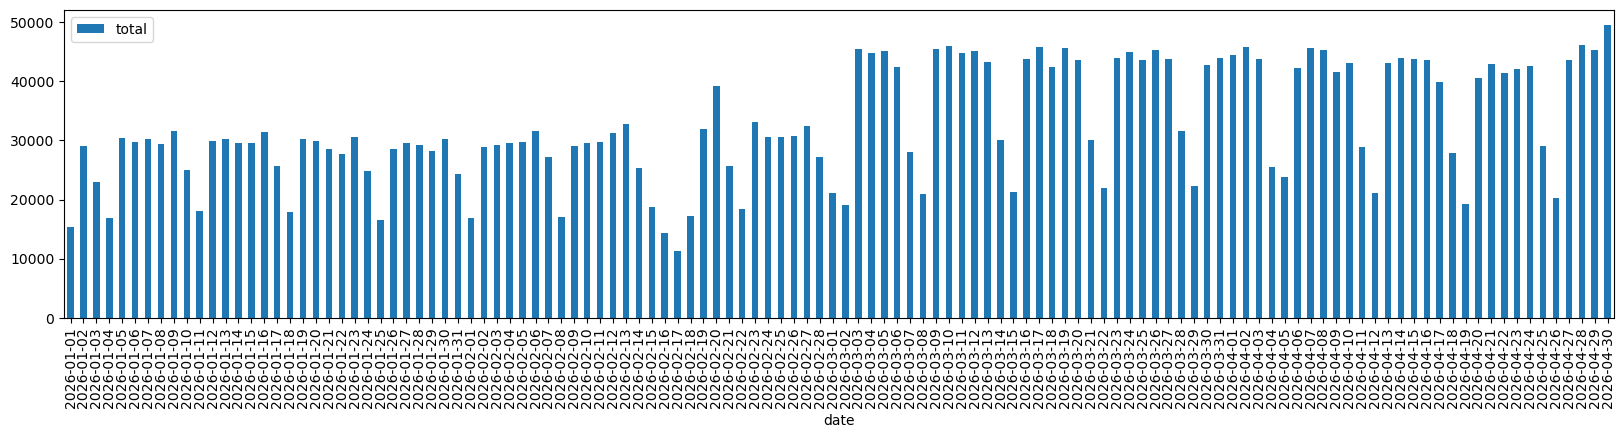

In [37]:
import matplotlib.pyplot as plt
data = df.groupby(['name','date']).sum().reset_index()
gdata = data[['name','date','total']]
pknu = gdata[gdata['name'] =='경성대부경대']
pknu.plot(
    figsize=(20,4),
    kind = 'bar',
    x = 'date',
    y = 'total'
)
plt.xticks(rotation=90)
plt.show()

In [ ]:
mdata = gdata.groupby('name').sum().reset_index()
tdata = mdata[['name','total']]
tdata

In [46]:
total = tdata.sort_values('total',ascending =False)
total = total[:20]
total

,name,total
70,서면,15442639
83,연산,6546162
61,부산역,5854705
65,사상,5529064
72,센텀시티,4971878
36,동래,4759891
23,남포,4453665
104,하단,4438206
88,자갈치,4340249
33,덕천,4305480


In [44]:
# !pip install squarify

Text(0.2, 0.4, '한글')

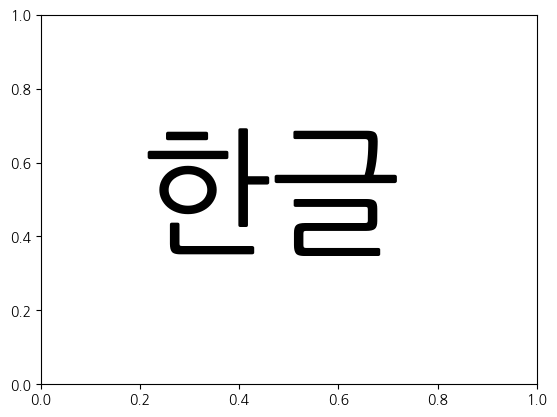

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

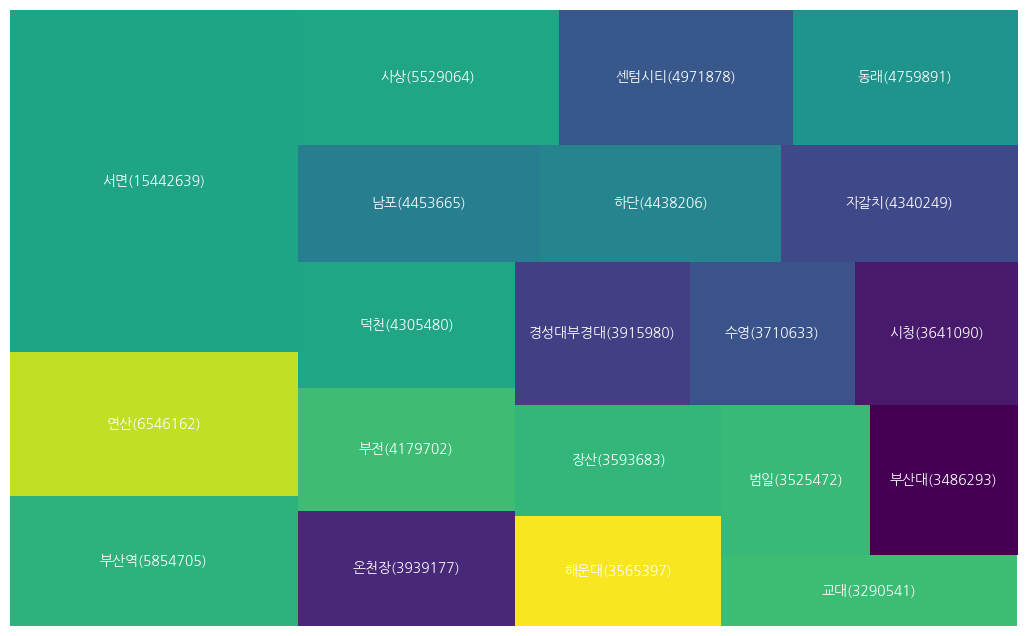

In [74]:
import squarify as sq
plt.figure(figsize=(13,8))
sq.plot(sizes=total['total'], label=[ f"{n}({t})" for n, t in zip(total['name'],total['total'])] )
plt.rcParams['font.size'] = 10
plt.rcParams['text.color'] = 'white'
plt.gca().invert_yaxis() # y 축뒤집기
plt.axis("off") # 축 인덱스 끄기
plt.show()